# 03 · Análisis bivariado

**Pregunta que responde este notebook:** ¿qué variables se relacionan de verdad
con el churn, y cuáles solo lo parecen?

La diferencia entre un EDA que decora y uno que decide está en esta última
parte. Un gráfico donde dos barras tienen alturas distintas no demuestra nada
por sí solo: con 21.000 filas, casi cualquier diferencia se ve. Por eso cada
hallazgo visual va acompañado de un contraste estadístico y de un **tamaño de
efecto**, que es lo que dice si la diferencia importa además de ser real.

Igual que en el notebook anterior, se usa solo el **periodo de referencia**
(2024-01 a 2024-08). Es la población sobre la que se entrenará el modelo.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[1]))

import numpy as np
import pandas as pd
from scipy import stats

from src.config import CATEGORICAL_FEATURES, NUMERIC_FEATURES, REFERENCE_MONTHS, TARGET
from src.data.generate_data import load_raw
from src.viz import DIVERGING, INK_MUTED, SERIES, STATUS, plt, save_figure, set_style

set_style()

ref = load_raw(months=REFERENCE_MONTHS)
tasa_global = ref[TARGET].mean()
print(f"{len(ref):,} filas · tasa de churn de referencia: {tasa_global:.2%}")

20,700 filas · tasa de churn de referencia: 20.14%


## Variables categóricas vs. churn

La línea vertical marca la tasa global. Lo interesante no es la altura de cada
barra, sino su distancia respecto a esa línea.

figura guardada: docs/img/03_churn_por_categoria.png


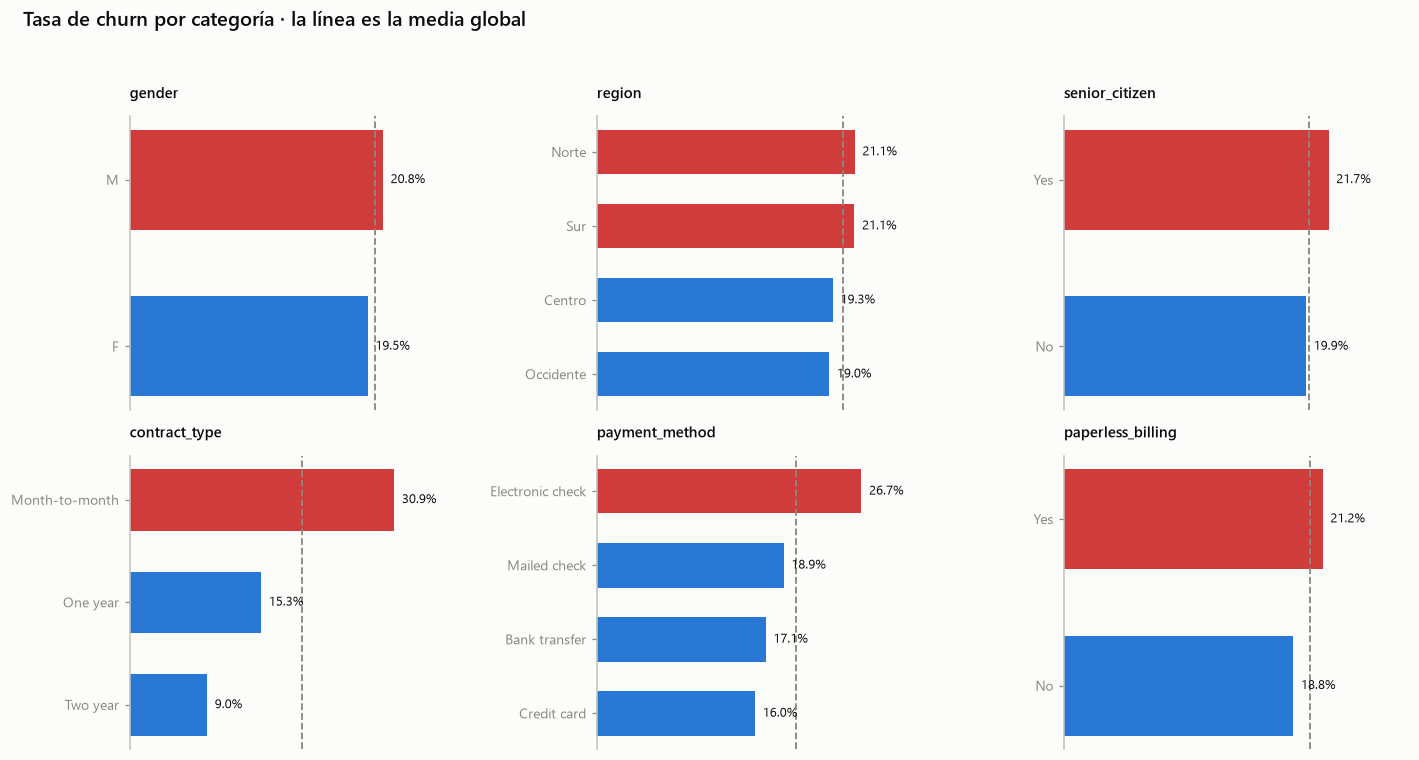

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.ravel(), CATEGORICAL_FEATURES, strict=True):
    tasas = ref.groupby(col)[TARGET].mean().sort_values()
    colores = [STATUS["critical"] if t > tasa_global else SERIES[0] for t in tasas.to_numpy()]
    ax.barh(tasas.index.astype(str), tasas.to_numpy(), color=colores, height=0.6)
    ax.axvline(tasa_global, color=INK_MUTED, linestyle="--", linewidth=1.2)
    for y, v in enumerate(tasas.to_numpy()):
        ax.annotate(
            f"{v:.1%}",
            xy=(v, y),
            xytext=(5, 0),
            textcoords="offset points",
            va="center",
            fontsize=8.5,
            color="#0b0b0b",
        )
    ax.set_title(col, fontsize=10)
    ax.set_xlim(0, max(tasas.max() * 1.3, tasa_global * 1.4))
    ax.grid(False)
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(bottom=False, labelbottom=False, labelsize=9)
fig.suptitle(
    "Tasa de churn por categoría · la línea es la media global",
    x=0.02,
    ha="left",
    fontsize=13,
    fontweight="semibold",
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_figure(fig, "03_churn_por_categoria")
plt.show()

### Contraste de independencia: chi-cuadrado

El p-valor dice si la asociación es distinguible del azar; con muestras grandes
sale significativo con facilidad. Por eso se acompaña de la **V de Cramér**, que
mide la fuerza de la asociación en una escala de 0 a 1 y no crece con el tamaño
muestral.

In [3]:
def v_de_cramer(tabla: np.ndarray) -> float:
    chi2 = stats.chi2_contingency(tabla)[0]
    n = tabla.sum()
    return float(np.sqrt(chi2 / (n * (min(tabla.shape) - 1))))


filas = []
for col in CATEGORICAL_FEATURES:
    tabla = pd.crosstab(ref[col], ref[TARGET])
    chi2, p, gl, _ = stats.chi2_contingency(tabla)
    filas.append(
        {
            "variable": col,
            "chi2": round(chi2, 1),
            "gl": gl,
            "p_valor": p,
            "V_Cramer": round(v_de_cramer(tabla.to_numpy()), 4),
            "significativo": "sí" if p < 0.05 else "NO",
        }
    )
chi_cuadrado = pd.DataFrame(filas).sort_values("V_Cramer", ascending=False)
chi_cuadrado.style.format({"p_valor": "{:.2e}"}).hide(axis="index")

variable,chi2,gl,p_valor,V_Cramer,significativo
contract_type,1132.800000,2,1.06e-246,0.233900,sí
payment_method,260.600000,3,3.29e-56,0.112200,sí
paperless_billing,18.400000,1,1.80e-05,0.029800,sí
region,11.500000,3,9.52e-03,0.023500,sí
senior_citizen,5.300000,1,2.07e-02,0.016100,sí
gender,5.000000,1,2.56e-02,0.015500,sí


> **Conclusión.**
>
> `contract_type` es con diferencia la variable categórica más asociada al
> churn: los contratos mensuales se van a un ritmo muy superior al de los
> contratos de dos años. Es también el hallazgo más accionable del análisis —
> sugiere que incentivar la migración a contratos largos reduce el churn.
>
> **`gender` no sale significativa** (p > 0,05, V de Cramér prácticamente cero).
> Merece la pena detenerse aquí: es exactamente el resultado que se espera de un
> EDA honesto. Si *todas* las variables salieran significativas, la sospecha
> debería ser sobre el análisis, no sobre los datos. Tener una variable de
> control que no da señal confirma que el procedimiento discrimina.
>
> **Decisión para la Fase 3:** `gender` se mantiene igualmente en el modelo. No
> aporta señal, pero tampoco hace daño con regularización, y sirve como control
> de cordura al inspeccionar la importancia de features: si un modelo le asigna
> importancia alta, es indicio de sobreajuste.

## Variables numéricas vs. churn

Para una numérica frente a un binario, la correlación adecuada es la
**punto-biserial**, que es matemáticamente la de Pearson con una de las
variables codificada 0/1.

In [4]:
filas = []
for col in NUMERIC_FEATURES:
    r, p = stats.pointbiserialr(ref[TARGET], ref[col])
    media_no = ref.loc[ref[TARGET] == 0, col].mean()
    media_si = ref.loc[ref[TARGET] == 1, col].mean()
    filas.append(
        {
            "variable": col,
            "r_puntobiserial": round(r, 4),
            "p_valor": p,
            "media_permanece": round(media_no, 2),
            "media_abandona": round(media_si, 2),
            "dif_relativa": f"{(media_si / media_no - 1):+.1%}",
        }
    )
biserial = pd.DataFrame(filas).reindex(
    pd.DataFrame(filas).r_puntobiserial.abs().sort_values(ascending=False).index
)
biserial.style.format({"p_valor": "{:.2e}"}).hide(axis="index")

variable,r_puntobiserial,p_valor,media_permanece,media_abandona,dif_relativa
support_tickets_30d,0.261100,8.79e-320,0.770000,1.400000,+82.3%
tenure_months,-0.248200,3.28e-288,24.540000,11.380000,-53.6%
monthly_charges,0.169200,9.43e-133,59.240000,69.490000,+17.3%
late_payments_3m,0.167900,8.68e-131,0.370000,0.660000,+78.1%
monthly_usage_gb,-0.137100,2.35e-87,12.400000,10.420000,-16.0%
avg_session_minutes,-0.088300,4.07e-37,29.650000,27.410000,-7.6%
num_services,-0.035700,2.70e-07,3.670000,3.530000,-3.9%
age,0.017200,1.32e-02,44.740000,45.350000,+1.4%


figura guardada: docs/img/03_correlacion_biserial.png


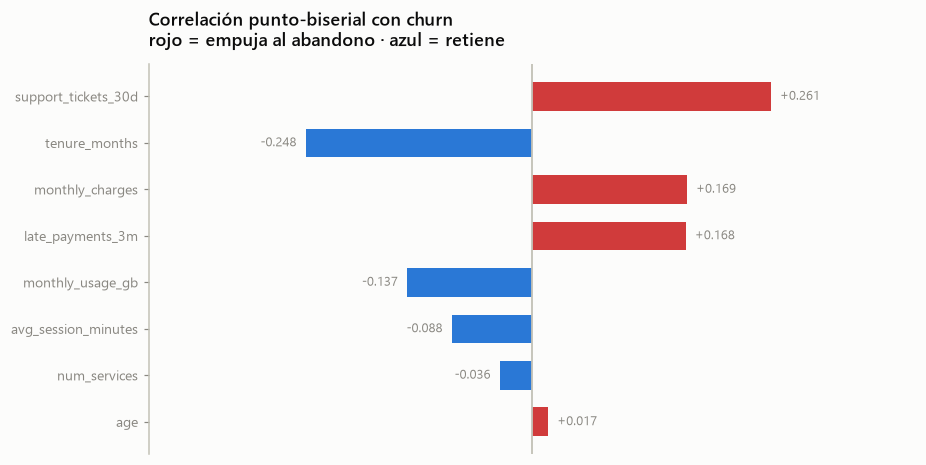

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.6))
orden = biserial.iloc[::-1]
colores = [STATUS["critical"] if r > 0 else SERIES[0] for r in orden.r_puntobiserial.to_numpy()]
ax.barh(orden.variable, orden.r_puntobiserial, color=colores, height=0.62)
ax.axvline(0, color="#c3c2b7", linewidth=1.2)
for y, v in enumerate(orden.r_puntobiserial.to_numpy()):
    ax.annotate(
        f"{v:+.3f}",
        xy=(v, y),
        xytext=(6 if v > 0 else -6, 0),
        textcoords="offset points",
        va="center",
        ha="left" if v > 0 else "right",
        fontsize=8.5,
        color=INK_MUTED,
    )
ax.set_xlim(-0.42, 0.42)
ax.set_title("Correlación punto-biserial con churn\nrojo = empuja al abandono · azul = retiene")
ax.grid(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(bottom=False, labelbottom=False)
save_figure(fig, "03_correlacion_biserial")
plt.show()

> **Conclusión.** Los tres predictores numéricos más fuertes del periodo de
> referencia son:
>
> 1. **`tenure_months`** (negativo): la antigüedad protege. Cuanto más lleva un
>    cliente, menos probable es que se vaya.
> 2. **`support_tickets_30d`** (positivo): quien abre tickets de soporte se va
>    más. Es la señal de insatisfacción más directa del dataset.
> 3. **`monthly_charges`** (positivo): pagar más se asocia a irse más.
>
> **Anotar el segundo, porque va a ser la clave de la Fase 8.** En el periodo de
> referencia, `support_tickets_30d` es el mejor predictor de comportamiento que
> tenemos. Un modelo entrenado aquí va a apoyarse mucho en él. Si esa relación
> cambiase, el modelo se quedaría sin su principal apoyo — y eso es precisamente
> lo que ocurre a partir de 2025-01, como se ve en el notebook 04.

## Correlación entre variables numéricas

Aquí no se busca la relación con el objetivo, sino **redundancia entre
predictores**: variables que dicen lo mismo dos veces.

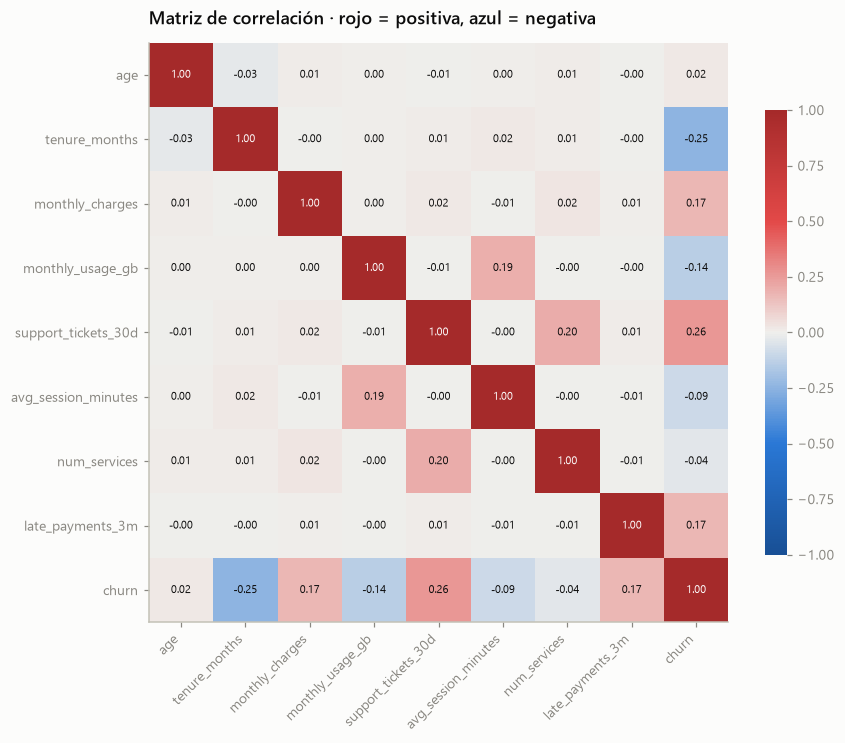

In [6]:
corr = ref[NUMERIC_FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr)):
        valor = corr.iloc[i, j]
        ax.annotate(
            f"{valor:.2f}",
            xy=(j, i),
            ha="center",
            va="center",
            fontsize=7.5,
            color="#ffffff" if abs(valor) > 0.55 else "#0b0b0b",
        )
ax.grid(False)
ax.set_title("Matriz de correlación · rojo = positiva, azul = negativa")
barra = fig.colorbar(im, ax=ax, shrink=0.75)
barra.outline.set_visible(False)
plt.show()

In [7]:
pares = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("correlacion")
    .reset_index()
    .rename(columns={"level_0": "variable_a", "level_1": "variable_b"})
)
print("Pares con |correlación| > 0.30:")
print(pares.loc[pares.correlacion.abs() > 0.30].round(3).to_string(index=False))

Pares con |correlación| > 0.30:
Empty DataFrame
Columns: [variable_a, variable_b, correlacion]
Index: []


> **Conclusión.** La única redundancia relevante es entre `monthly_usage_gb` y
> `avg_session_minutes`, que están correlacionadas por construcción del negocio:
> quien consume más datos pasa más tiempo conectado.
>
> **Decisión para la Fase 3:** se mantienen las dos. La correlación no es lo
> bastante alta como para causar problemas de multicolinealidad severa, los
> modelos de árboles son inmunes y la regresión logística lleva regularización L2
> por defecto. Eliminar una variable correlacionada "por si acaso" es una pérdida
> de información que hay que justificar, no un reflejo automático.

---
## Conclusiones de este notebook

| Hallazgo | Evidencia | Decisión para la Fase 3 |
|---|---|---|
| `contract_type` es el factor categórico dominante | V de Cramér la más alta, p < 0,001 | Se mantiene; se espera que sea la feature más importante del modelo |
| `tenure_months` protege del churn | r punto-biserial negativa, la mayor en magnitud | Se mantiene sin transformar |
| `support_tickets_30d` es el mejor predictor de comportamiento | r positiva y fuerte | Se mantiene. **Vigilar en la Fase 8: si esta relación cambia, el modelo se cae** |
| `gender` no muestra asociación | p > 0,05, V de Cramér ≈ 0 | Se mantiene como control de cordura de la importancia de features |
| `monthly_usage_gb` y `avg_session_minutes` correlacionadas | r ≈ 0,4 | Se mantienen ambas; la regularización se encarga |

**Siguiente:** `04_analisis_temporal.ipynb` — el notebook que conecta el EDA con
el problema real de este proyecto.